In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

In [2]:
import os
project_path = r'C:\Users\Wenyanxiaoyao\Desktop\Unlocking-label-efficient-battery-health-estimation-via-physics-feature-guided-learning'
os.chdir(project_path)

In [3]:
import joblib

fn = 'result/result_for_loco1/semi_MTL1_locv1.joblib'
data = joblib.load(fn)
print(data.keys())

dict_keys(['num_cell_6', 'num_cell_8', 'num_cell_10'])


In [11]:
all_rmse = []
mean_rmse = []
all_mape = []
mean_mape = []

In [12]:
for key in list(data.keys())[:]:
    d1 = data[key]
    rmse0 = []
    mape0 = []
    for dict1 in d1:
        y_true = dict1['y_true']
        y_pred = dict1['y_pred']
        rmse = root_mean_squared_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)*100
        rmse0.append(rmse)
        mape0.append(mape)
        
    mean_rmse.append(round(np.mean(rmse0),4))
    mean_mape.append(round(np.mean(mape0),2))
    all_rmse.append(rmse0)
    all_mape.append(mape0)

In [13]:
print(mean_mape)
print(mean_rmse)
print(f'Number of repeated trials: {len(mape0)}')

[2.65, 2.64, 2.42]
[0.0326, 0.031, 0.0303]
Number of repeated trials: 20


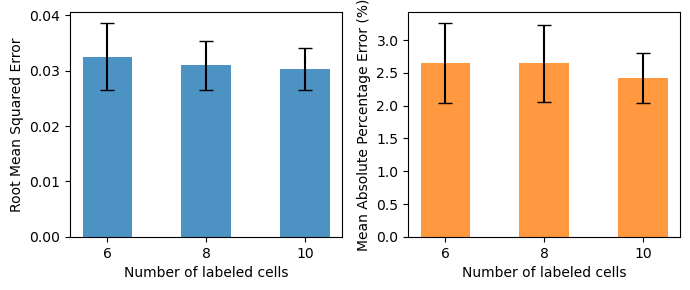

In [20]:
# 计算均值与标准差
mean_rmse_arr = [np.mean(x) for x in all_rmse]
std_rmse_arr = [np.std(x) for x in all_rmse]
mean_mape_arr = [np.mean(x) for x in all_mape]
std_mape_arr = [np.std(x) for x in all_mape]

x_pos = np.arange(3)  # [0, 1, 2]

fig, ax = plt.subplots(1, 2, figsize=(7, 3))

ax[0].bar(x_pos, mean_rmse_arr, yerr=std_rmse_arr,
          capsize=5, color='C0', alpha=0.8, width=0.5)
ax[0].set_xticks(x_pos)
ax[0].set_xticklabels(['6', '8', '10'])
ax[0].set_xlabel('Number of labeled cells')
ax[0].set_ylabel('Root Mean Squared Error')

ax[1].bar(x_pos, mean_mape_arr, yerr=std_mape_arr,
          capsize=5, color='C1', alpha=0.8, width=0.5)
ax[1].set_xticks(x_pos)
ax[1].set_xticklabels(['6', '8', '10'])
ax[1].set_xlabel('Number of labeled cells')
ax[1].set_ylabel('Mean Absolute Percentage Error (%)')

plt.tight_layout()
plt.show()

### Display the results of a single trial

Labeled cells: 6, Root Mean Squared Error:  0.029, Mean Absolute Percentage Error:  2.42%
Labeled cells: 8, Root Mean Squared Error:  0.030, Mean Absolute Percentage Error:  2.59%
Labeled cells: 10, Root Mean Squared Error:  0.028, Mean Absolute Percentage Error:  2.20%


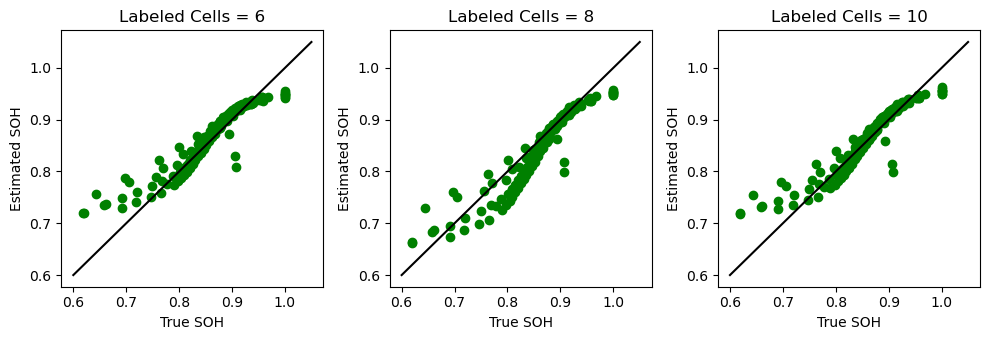

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
labeled_cells = [6, 8, 10]
for i, key in enumerate(list(data.keys())):
    visual_trial = data[key][0]  # 1st trial
    y_true = visual_trial['y_true']
    y_pred = visual_trial['y_pred']
    mape = mean_absolute_percentage_error(y_true, y_pred)*100
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f'Labeled cells: {labeled_cells[i]}, Root Mean Squared Error: {rmse: .3f}, Mean Absolute Percentage Error: {mape: .2f}%')
    
    ax[i].plot([0.6, 1.05], [0.6, 1.05], 'k')
    ax[i].scatter(y_true, y_pred, color='green')
    ax[i].set_xlabel('True SOH')
    ax[i].set_ylabel('Estimated SOH')
    ax[i].set_title(f'Labeled Cells = {labeled_cells[i]}')
plt.tight_layout()
plt.show()